## Notebook Guide

This notebook reproduces the modelling workflow used in Chapter 4 and the extended modelling exercises developed afterwards.

### Structure
- **Imports and data loading**: load the borough-month panel and inspect its scope.
- **Feature engineering**: create seasonal terms, lagged predictors, and rolling workload variables.
- **Train/test datasets**: define the temporal split and assemble target-specific modelling datasets.
- **Model utilities**: define the validation scheme, benchmark models, and helper functions.
- **Baseline modelling**: estimate the original comparison models and store predictions and metrics.
- **Diagnostics and interpretation**: evaluate generalization, fold stability, and borough-level variation.
- **Extended modelling**: add XGBoost, tuning, reduced-feature experiments, SHAP, and the final comparison.

The code below is kept in execution order so that the stored objects can be reused in later sections without rewriting the core pipeline.


### Imports and data loading

In [1]:
# Core data and modelling libraries.
import pandas as pd
import numpy as np
import shap

# Model selection, preprocessing, and evaluation utilities.
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor

# Econometric benchmark used as a fixed-effects reference.
import statsmodels.formula.api as smf


In [2]:
# Input dataset created in the preprocessing stage.
DATA_PATH = r"C:\Users\Jose Miguel\OneDrive\Ambiente de Trabalho\NOVA\TESE\processed\borough_month_panel_resilience_inputs.csv"


In [3]:
# Load the borough-month panel and enforce chronological ordering within each borough.
df = pd.read_csv(DATA_PATH)

df["year_month"] = pd.to_datetime(df["year_month"])
df = df.sort_values(["lpa_name", "year_month"]).reset_index(drop=True)


In [4]:
# Initial inspection of panel size, coverage, and available variables.
print("Shape:", df.shape)
print("Boroughs:", df["lpa_name"].nunique())
print("Date range:", df["year_month"].min(), "to", df["year_month"].max())
print("Columns:")
print(df.columns.tolist())


Shape: (2662, 16)
Boroughs: 32
Date range: 2019-01-01 00:00:00 to 2025-12-01 00:00:00
Columns:
['lpa_name', 'year_month', 'median_decision_time', 'approval_rate', 'decision_volume', 'p90_volume', 'shock_flag', 'shock_intensity', 'baseline_mdt', 'baseline_ar', 'impact_mdt', 'impact_ar', 'shock_month', 'impact_mdt_norm', 'impact_ar_norm', 'resilience_index']


### Feature Engineering

In [5]:
# Month is extracted to build cyclical seasonal terms.
df["month"] = df["year_month"].dt.month
df["year"] = df["year_month"].dt.year

# Sinusoidal encoding preserves the cyclical structure of calendar months.
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)


In [6]:
def add_lags(data, column, group_col="lpa_name", lags=(1, 3)):
    # Lags are computed within borough to avoid mixing information across authorities.
    for lag in lags:
        data[f"{column}_lag{lag}"] = data.groupby(group_col)[column].shift(lag)
    return data


In [7]:
# Target lags provide short-term memory for each forecasting task.
for col in ["median_decision_time", "approval_rate"]:
    df = add_lags(df, col, lags=(1, 3))


In [8]:
# Recent workload is captured with borough-specific lags of decision volume.
df = add_lags(df, "decision_volume", lags=(1, 3))


In [9]:
# Shock variables are lagged so that only past disruption information is used.
df = add_lags(df, "shock_flag", lags=(1, 3))
df = add_lags(df, "shock_intensity", lags=(1, 3))


In [10]:
# The rolling workload term summarizes the previous three months and excludes the current month.
df["decision_volume_roll3"] = (
    df.groupby("lpa_name")["decision_volume"]
      .shift(1)
      .rolling(3)
      .mean()
      .reset_index(level=0, drop=True)
)


In [11]:
# Two predictive tasks are evaluated in parallel.
targets = [
    "median_decision_time",
    "approval_rate"
]


In [12]:
# Features shared by both targets.
common_features = [
    "decision_volume_lag1",
    "decision_volume_lag3",
    "decision_volume_roll3",
    "shock_flag_lag1",
    "shock_flag_lag3",
    "shock_intensity_lag1",
    "shock_intensity_lag3",
    "p90_volume",
    "baseline_mdt",
    "baseline_ar",
    "month_sin",
    "month_cos"
]


In [13]:
# Each target receives the common features plus its own lagged outcome variables.
feature_sets = {
    "median_decision_time": common_features + [
        "median_decision_time_lag1",
        "median_decision_time_lag3"
    ],
    "approval_rate": common_features + [
        "approval_rate_lag1",
        "approval_rate_lag3"
    ]
}


In [14]:
# Quick check of the target-specific feature spaces used later in the notebook.
print("\nEngineered lag/rolling columns created.")
for target, cols in feature_sets.items():
    print(f"\nTarget: {target}")
    print(cols)



Engineered lag/rolling columns created.

Target: median_decision_time
['decision_volume_lag1', 'decision_volume_lag3', 'decision_volume_roll3', 'shock_flag_lag1', 'shock_flag_lag3', 'shock_intensity_lag1', 'shock_intensity_lag3', 'p90_volume', 'baseline_mdt', 'baseline_ar', 'month_sin', 'month_cos', 'median_decision_time_lag1', 'median_decision_time_lag3']

Target: approval_rate
['decision_volume_lag1', 'decision_volume_lag3', 'decision_volume_roll3', 'shock_flag_lag1', 'shock_flag_lag3', 'shock_intensity_lag1', 'shock_intensity_lag3', 'p90_volume', 'baseline_mdt', 'baseline_ar', 'month_sin', 'month_cos', 'approval_rate_lag1', 'approval_rate_lag3']


### Train/Test datasets


In [15]:
# Temporal split: all observations before 2025 are used for training; 2025 is reserved for out-of-sample testing.
train = df[df["year_month"] < "2025-01-01"].copy()
test  = df[df["year_month"] >= "2025-01-01"].copy()


In [16]:
def regression_metrics(y_true, y_pred):
    # Common evaluation metrics used throughout the notebook.
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "R2": r2_score(y_true, y_pred)
    }


In [17]:
# Build target-specific train/test objects once so that later sections can reuse the same inputs.
datasets = {}

for target, cols in feature_sets.items():
    # Rows with missing predictors or missing target values are excluded separately for each task.
    train_t = train.dropna(subset=cols + [target]).copy()
    test_t = test.dropna(subset=cols + [target]).copy()

    datasets[target] = {
        "train": train_t,
        "test": test_t,
        "X_train": train_t[cols].copy(),
        "X_test": test_t[cols].copy(),
        "y_train": train_t[target].copy(),
        "y_test": test_t[target].copy(),
        "features": cols
    }


In [18]:
# Verify the temporal coverage and dimensionality of each modelling dataset.
for target in datasets:
    print(f"\n--- {target} ---")
    print("Train period:", datasets[target]["train"]["year_month"].min(), "to", datasets[target]["train"]["year_month"].max())
    print("Test period :", datasets[target]["test"]["year_month"].min(), "to", datasets[target]["test"]["year_month"].max())
    print("Train shape :", datasets[target]["X_train"].shape)
    print("Test shape  :", datasets[target]["X_test"].shape)
    print("Features    :", datasets[target]["features"])



--- median_decision_time ---
Train period: 2019-04-01 00:00:00 to 2024-12-01 00:00:00
Test period : 2025-01-01 00:00:00 to 2025-12-01 00:00:00
Train shape : (2207, 14)
Test shape  : (359, 14)
Features    : ['decision_volume_lag1', 'decision_volume_lag3', 'decision_volume_roll3', 'shock_flag_lag1', 'shock_flag_lag3', 'shock_intensity_lag1', 'shock_intensity_lag3', 'p90_volume', 'baseline_mdt', 'baseline_ar', 'month_sin', 'month_cos', 'median_decision_time_lag1', 'median_decision_time_lag3']

--- approval_rate ---
Train period: 2019-04-01 00:00:00 to 2024-12-01 00:00:00
Test period : 2025-01-01 00:00:00 to 2025-12-01 00:00:00
Train shape : (2207, 14)
Test shape  : (359, 14)
Features    : ['decision_volume_lag1', 'decision_volume_lag3', 'decision_volume_roll3', 'shock_flag_lag1', 'shock_flag_lag3', 'shock_intensity_lag1', 'shock_intensity_lag3', 'p90_volume', 'baseline_mdt', 'baseline_ar', 'month_sin', 'month_cos', 'approval_rate_lag1', 'approval_rate_lag3']


### Model Utilities

In [19]:
# Expanding time-series cross-validation preserves temporal ordering during model selection.
tscv = TimeSeriesSplit(n_splits=5)


In [20]:
def run_persistence_baseline(target, test_df):
    # The persistence benchmark uses the most recent observed value of the target.
    if target == "median_decision_time":
        preds = test_df["median_decision_time_lag1"].values
    elif target == "approval_rate":
        preds = test_df["approval_rate_lag1"].values
    else:
        raise ValueError(f"Unsupported target: {target}")

    return preds


Ridge (with scaling)

In [21]:
def fit_ridge_with_cv(X_train, y_train):
    # All predictors are numeric, so the preprocessing pipeline only imputes and scales them.
    numeric_features = X_train.columns.tolist()

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features)
        ],
        remainder="drop"
    )

    ridge_pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", Ridge())
    ])

    # Ridge is tuned only through the regularization strength.
    param_grid = {
        "model__alpha": [0.1, 1.0, 10.0, 100.0]
    }

    search = GridSearchCV(
        estimator=ridge_pipe,
        param_grid=param_grid,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    return search


Random Forest

In [22]:
def fit_rf_with_cv(X_train, y_train):
    # Random Forest provides a nonlinear benchmark that can capture threshold effects and interactions.
    rf = RandomForestRegressor(random_state=42)

    param_grid = {
        "n_estimators": [200, 400],
        "max_depth": [4, 8, None],
        "min_samples_leaf": [1, 3, 5],
        "max_features": ["sqrt", 0.7]
    }

    search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    return search


HistGradientBoosting

In [23]:
def fit_hgb_with_cv(X_train, y_train):
    # HistGradientBoosting is used as a second nonlinear benchmark with boosted trees.
    hgb = HistGradientBoostingRegressor(random_state=42)

    param_grid = {
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [3, 5, None],
        "max_iter": [200, 400],
        "min_samples_leaf": [10, 20]
    }

    search = GridSearchCV(
        estimator=hgb,
        param_grid=param_grid,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    return search


In [24]:
def fit_fixed_effects(train_df, target):
    # The fixed-effects benchmark uses borough dummies and a reduced set of lagged predictors.
    if target == "median_decision_time":
        formula = (
            "median_decision_time ~ "
            "median_decision_time_lag1 + median_decision_time_lag3 + "
            "decision_volume_lag1 + decision_volume_lag3 + "
            "shock_intensity_lag1 + "
            "month_sin + month_cos + "
            "C(lpa_name)"
        )
    elif target == "approval_rate":
        formula = (
            "approval_rate ~ "
            "approval_rate_lag1 + approval_rate_lag3 + "
            "decision_volume_lag1 + decision_volume_lag3 + "
            "shock_intensity_lag1 + "
            "month_sin + month_cos + "
            "C(lpa_name)"
        )
    else:
        raise ValueError(f"Unsupported target: {target}")

    model = smf.ols(formula=formula, data=train_df).fit()
    return model


In [25]:
def print_best_params(model_name, search_obj):
    # Report the selected hyperparameters and the corresponding validation score.
    print(f"{model_name} best params: {search_obj.best_params_}")
    print(f"{model_name} best CV RMSE: {-search_obj.best_score_:.4f}")


In [26]:
# ============================================
# E. MODEL FITTING AND PREDICTION STORAGE
# ============================================

all_results = {}

for target, data in datasets.items():
    print(f"\n==============================")
    print(f"TARGET: {target}")
    print(f"==============================")

    # Reuse the pre-built train/test objects for the current target.
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]
    train_df = data["train"].copy()
    test_df = data["test"].copy()

    target_results = {}

    # ----------------------------------------
    # 1) Persistence baseline
    # ----------------------------------------
    pred_persistence = run_persistence_baseline(target, test_df)
    target_results["Persistence"] = regression_metrics(y_test, pred_persistence)

    # ----------------------------------------
    # 2) Ridge
    # ----------------------------------------
    ridge_search = fit_ridge_with_cv(X_train, y_train)
    ridge_best = ridge_search.best_estimator_
    pred_ridge = ridge_best.predict(X_test)

    target_results["Ridge"] = regression_metrics(y_test, pred_ridge)
    print_best_params("Ridge", ridge_search)

    # ----------------------------------------
    # 3) Random Forest
    # ----------------------------------------
    rf_search = fit_rf_with_cv(X_train, y_train)
    rf_best = rf_search.best_estimator_
    pred_rf = rf_best.predict(X_test)

    target_results["RandomForest"] = regression_metrics(y_test, pred_rf)
    print_best_params("RandomForest", rf_search)

    # ----------------------------------------
    # 4) HistGradientBoosting
    # ----------------------------------------
    hgb_search = fit_hgb_with_cv(X_train, y_train)
    hgb_best = hgb_search.best_estimator_
    pred_hgb = hgb_best.predict(X_test)

    target_results["HistGradientBoosting"] = regression_metrics(y_test, pred_hgb)
    print_best_params("HistGradientBoosting", hgb_search)

    # ----------------------------------------
    # 5) Fixed Effects benchmark
    # ----------------------------------------
    fe_model = fit_fixed_effects(train_df, target)
    pred_fe = fe_model.predict(test_df)

    target_results["FixedEffects"] = regression_metrics(y_test, pred_fe)

    # Store the summary metrics in tabular form for later comparison blocks.
    metrics_df = pd.DataFrame(target_results).T

    # Store row-level predictions so that later sections can evaluate performance by borough and over time.
    pred_df = test_df[["lpa_name", "year_month", target]].copy()
    pred_df = pred_df.rename(columns={target: "actual"})
    pred_df["Persistence"] = pred_persistence
    pred_df["Ridge"] = pred_ridge
    pred_df["RandomForest"] = pred_rf
    pred_df["HistGradientBoosting"] = pred_hgb
    pred_df["FixedEffects"] = pred_fe.values if hasattr(pred_fe, "values") else pred_fe

    # Save all objects needed by the downstream diagnostics and interpretation sections.
    all_results[target] = {
        "metrics": metrics_df,
        "predictions": pred_df,
        "ridge_model": ridge_best,
        "rf_model": rf_best,
        "hgb_model": hgb_best,
        "fe_model": fe_model,
        "ridge_search": ridge_search,
        "rf_search": rf_search,
        "hgb_search": hgb_search,
        "feature_cols": data["features"]
    }



TARGET: median_decision_time


c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Ridge best params: {'model__alpha': 100.0}
Ridge best CV RMSE: 12.9394


c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


RandomForest best params: {'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 5, 'n_estimators': 400}
RandomForest best CV RMSE: 12.9061


...

c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Ridge best params: {'model__alpha': 10.0}
Ridge best CV RMSE: 0.0647


c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


RandomForest best params: {'max_depth': 8, 'max_features': 0.7, 'min_samples_leaf': 5, 'n_estimators': 400}
RandomForest best CV RMSE: 0.0711
HistGradientBoosting best params: {'learning_rate': 0.03, 'max_depth': 3, 'max_iter': 200, 'min_samples_leaf': 20}
HistGradientBoosting best CV RMSE: 0.0728


c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [27]:
# ============================================
# CV RMSE vs TEST RMSE SUMMARY
# ============================================

cv_test_summary_rows = []

for target in all_results:
    metrics_df = all_results[target]["metrics"]

    # Validation RMSE is taken from the best GridSearchCV score for each model.
    ridge_cv_rmse = -all_results[target]["ridge_search"].best_score_
    rf_cv_rmse = -all_results[target]["rf_search"].best_score_
    hgb_cv_rmse = -all_results[target]["hgb_search"].best_score_

    # Test RMSE is taken from the final holdout evaluation table.
    ridge_test_rmse = metrics_df.loc["Ridge", "RMSE"]
    rf_test_rmse = metrics_df.loc["RandomForest", "RMSE"]
    hgb_test_rmse = metrics_df.loc["HistGradientBoosting", "RMSE"]

    cv_test_summary_rows.extend([
        {
            "target": target,
            "model": "Ridge",
            "cv_rmse": ridge_cv_rmse,
            "test_rmse": ridge_test_rmse,
            "gap_test_minus_cv": ridge_test_rmse - ridge_cv_rmse
        },
        {
            "target": target,
            "model": "RandomForest",
            "cv_rmse": rf_cv_rmse,
            "test_rmse": rf_test_rmse,
            "gap_test_minus_cv": rf_test_rmse - rf_cv_rmse
        },
        {
            "target": target,
            "model": "HistGradientBoosting",
            "cv_rmse": hgb_cv_rmse,
            "test_rmse": hgb_test_rmse,
            "gap_test_minus_cv": hgb_test_rmse - hgb_cv_rmse
        }
    ])

cv_test_summary = pd.DataFrame(cv_test_summary_rows).round(4)

print(cv_test_summary)


                 target                 model  cv_rmse  test_rmse  \
0  median_decision_time                 Ridge  12.9394    42.0010   
1  median_decision_time          RandomForest  12.9061    41.5174   
2  median_decision_time  HistGradientBoosting  13.1300    41.6728   
3         approval_rate                 Ridge   0.0647     0.1025   
4         approval_rate          RandomForest   0.0711     0.1154   
5         approval_rate  HistGradientBoosting   0.0728     0.1196   

   gap_test_minus_cv  
0            29.0616  
1            28.6112  
2            28.5428  
3             0.0379  
4             0.0443  
5             0.0467  


In [28]:
# Baseline performance tables for the two targets.
overall_mdt = all_results["median_decision_time"]["metrics"].copy().round(3)
overall_ap = all_results["approval_rate"]["metrics"].copy().round(3)

print("MDT")
display(overall_mdt)

print("Approval Rate")
display(overall_ap)


MDT


,MAE,RMSE,R2
Persistence,7.625,44.603,-0.095
Ridge,9.137,42.001,0.029
RandomForest,7.218,41.517,0.051
HistGradientBoosting,7.293,41.673,0.044
FixedEffects,8.892,41.888,0.034


Approval Rate


,MAE,RMSE,R2
Persistence,0.054,0.099,0.664
Ridge,0.060,0.103,0.641
RandomForest,0.061,0.115,0.545
HistGradientBoosting,0.063,0.120,0.512
FixedEffects,0.059,0.102,0.648


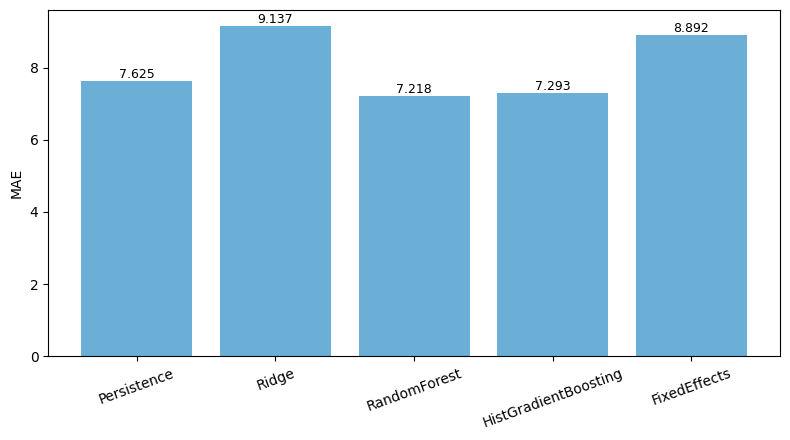

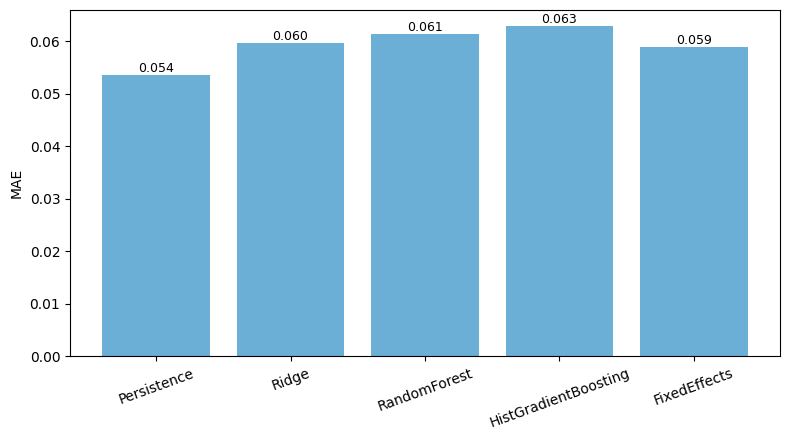

In [29]:
import matplotlib.pyplot as plt

# Plot baseline MAE by model for each target.
for target, label in [
    ("median_decision_time", "MDT"),
    ("approval_rate", "Approval Rate")
]:
    plot_df = all_results[target]["metrics"].reset_index()
    plot_df.columns = ["Model", "MAE", "RMSE", "R2"]

    plt.figure(figsize=(8, 4.5))
    bars = plt.bar(plot_df["Model"], plot_df["MAE"], color="#6BAED6", edgecolor="none")

    for bar, value in zip(bars, plot_df["MAE"]):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            value,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.ylabel("MAE")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


In [30]:
# ============================================
# F. BOROUGH-LEVEL EVALUATION
# ============================================

from sklearn.metrics import mean_absolute_error, root_mean_squared_error

def borough_level_metrics(pred_df):
    model_cols = ["Persistence", "Ridge", "RandomForest", "HistGradientBoosting", "FixedEffects"]
    rows = []

    for borough, g in pred_df.groupby("lpa_name"):
        row = {
            "lpa_name": borough,
            "n_obs": len(g)
        }

        for model in model_cols:
            row[f"{model}_MAE"] = mean_absolute_error(g["actual"], g[model])
            row[f"{model}_RMSE"] = root_mean_squared_error(g["actual"], g[model])

        rows.append(row)

    out = pd.DataFrame(rows).sort_values("lpa_name").reset_index(drop=True)
    return out


# Run for each target
borough_mdt = borough_level_metrics(all_results["median_decision_time"]["predictions"])
borough_ap = borough_level_metrics(all_results["approval_rate"]["predictions"])

print("Borough-level MDT results")
print(borough_mdt.head())

print("\nBorough-level Approval Rate results")
print(borough_ap.head())

Borough-level MDT results
  lpa_name  n_obs  Persistence_MAE  Persistence_RMSE  Ridge_MAE  Ridge_RMSE  \
0   Barnet     12         4.083333          8.098354   3.582138    4.349786   
1   Bexley     12         1.666667          2.236068   3.260366    3.890603   
2    Brent     12         0.333333          0.577350   1.748735    1.988330   
3  Bromley      8        12.375000         33.254699  11.510752   31.034407   
4   Camden     12         6.250000          8.708234  32.503252   33.061388   

   RandomForest_MAE  RandomForest_RMSE  HistGradientBoosting_MAE  \
0          2.813079           3.520187                  2.568128   
1          1.119152           1.828727                  1.209448   
2          0.281297           0.509958                  0.256109   
3         11.772040          32.210611                 12.197003   
4          9.817175          10.801623                  9.020790   

   HistGradientBoosting_RMSE  FixedEffects_MAE  FixedEffects_RMSE  
0                   3.

In [31]:
# --------------------------------------------
# Compare best model vs persistence by borough
# --------------------------------------------

best_model_mdt = all_results["median_decision_time"]["metrics"]["MAE"].idxmin()
best_model_ap = all_results["approval_rate"]["metrics"]["MAE"].idxmin()

# MDT
borough_mdt_compare = borough_mdt[[
    "lpa_name", "n_obs", "Persistence_MAE", f"{best_model_mdt}_MAE"
]].copy()
borough_mdt_compare["MAE_gain_vs_persistence"] = (
    borough_mdt_compare["Persistence_MAE"] - borough_mdt_compare[f"{best_model_mdt}_MAE"]
)
borough_mdt_compare = borough_mdt_compare.sort_values("MAE_gain_vs_persistence", ascending=False)

# AP
if best_model_ap == "Persistence":
    borough_ap_compare = borough_ap[[
        "lpa_name", "n_obs", "Persistence_MAE"
    ]].copy()
    borough_ap_compare["BestModel_MAE"] = borough_ap_compare["Persistence_MAE"]
    borough_ap_compare["MAE_gain_vs_persistence"] = 0.0
else:
    borough_ap_compare = borough_ap[[
        "lpa_name", "n_obs", "Persistence_MAE", f"{best_model_ap}_MAE"
    ]].copy()
    borough_ap_compare["BestModel_MAE"] = borough_ap_compare[f"{best_model_ap}_MAE"]
    borough_ap_compare["MAE_gain_vs_persistence"] = (
        borough_ap_compare["Persistence_MAE"] - borough_ap_compare[f"{best_model_ap}_MAE"]
    )

borough_ap_compare = borough_ap_compare.sort_values("MAE_gain_vs_persistence", ascending=False)

print("\nMDT: gain vs persistence")
print(borough_mdt_compare.head(10))
print(borough_mdt_compare.tail(10))

print("\nApproval Rate: gain vs persistence")
print(borough_ap_compare.head(10))
print(borough_ap_compare.tail(10))


MDT: gain vs persistence
          lpa_name  n_obs  Persistence_MAE  RandomForest_MAE  \
30      Wandsworth     12        62.166667         40.229020   
25        Richmond     11         8.909091          7.421889   
5   City of London     12        15.666667         14.348110   
0           Barnet     12         4.083333          2.813079   
24       Redbridge     12         4.166667          3.540063   
3          Bromley      8        12.375000         11.772040   
26       Southwark     12         2.250000          1.675833   
1           Bexley     12         1.666667          1.119152   
28   Tower Hamlets     12         3.166667          2.664720   
17       Islington     12         4.916667          4.507824   

    MAE_gain_vs_persistence  
30                21.937646  
25                 1.487202  
5                  1.318557  
0                  1.270254  
24                 0.626603  
3                  0.602960  
26                 0.574167  
1                  0.547515  

In [32]:
# ============================================
# G. FEATURE IMPORTANCE FOR MDT
# ============================================

rf_mdt = all_results["median_decision_time"]["rf_model"]
rf_features = all_results["median_decision_time"]["feature_cols"]

rf_importance_mdt = pd.DataFrame({
    "feature": rf_features,
    "importance": rf_mdt.feature_importances_
}).sort_values("importance", ascending=False)

print("Random Forest feature importance - MDT")
print(rf_importance_mdt)

Random Forest feature importance - MDT
                      feature  importance
12  median_decision_time_lag1    0.486073
8                baseline_mdt    0.127036
13  median_decision_time_lag3    0.099272
9                 baseline_ar    0.060484
5        shock_intensity_lag1    0.042426
6        shock_intensity_lag3    0.040016
0        decision_volume_lag1    0.038364
2       decision_volume_roll3    0.037791
1        decision_volume_lag3    0.025719
10                  month_sin    0.018250
7                  p90_volume    0.012703
11                  month_cos    0.011028
4             shock_flag_lag3    0.000442
3             shock_flag_lag1    0.000396


In [33]:
from sklearn.inspection import permutation_importance

hgb_mdt = all_results["median_decision_time"]["hgb_model"]
X_test_mdt = datasets["median_decision_time"]["X_test"]
y_test_mdt = datasets["median_decision_time"]["y_test"]

perm_hgb_mdt = permutation_importance(
    hgb_mdt,
    X_test_mdt,
    y_test_mdt,
    n_repeats=20,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

hgb_importance_mdt = pd.DataFrame({
    "feature": all_results["median_decision_time"]["feature_cols"],
    "importance_mean": perm_hgb_mdt.importances_mean,
    "importance_std": perm_hgb_mdt.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nHistGradientBoosting permutation importance - MDT")
print(hgb_importance_mdt)


HistGradientBoosting permutation importance - MDT
                      feature  importance_mean  importance_std
12  median_decision_time_lag1         2.319499        0.161333
8                baseline_mdt         0.453244        0.072880
13  median_decision_time_lag3         0.424643        0.045943
5        shock_intensity_lag1         0.100012        0.031384
11                  month_cos         0.031375        0.012918
0        decision_volume_lag1         0.021801        0.049457
10                  month_sin         0.019330        0.049634
2       decision_volume_roll3         0.012544        0.038025
1        decision_volume_lag3         0.002652        0.024439
9                 baseline_ar         0.002613        0.006853
6        shock_intensity_lag3         0.000557        0.011060
3             shock_flag_lag1         0.000000        0.000000
4             shock_flag_lag3         0.000000        0.000000
7                  p90_volume        -0.019855        0.016287


### Plots

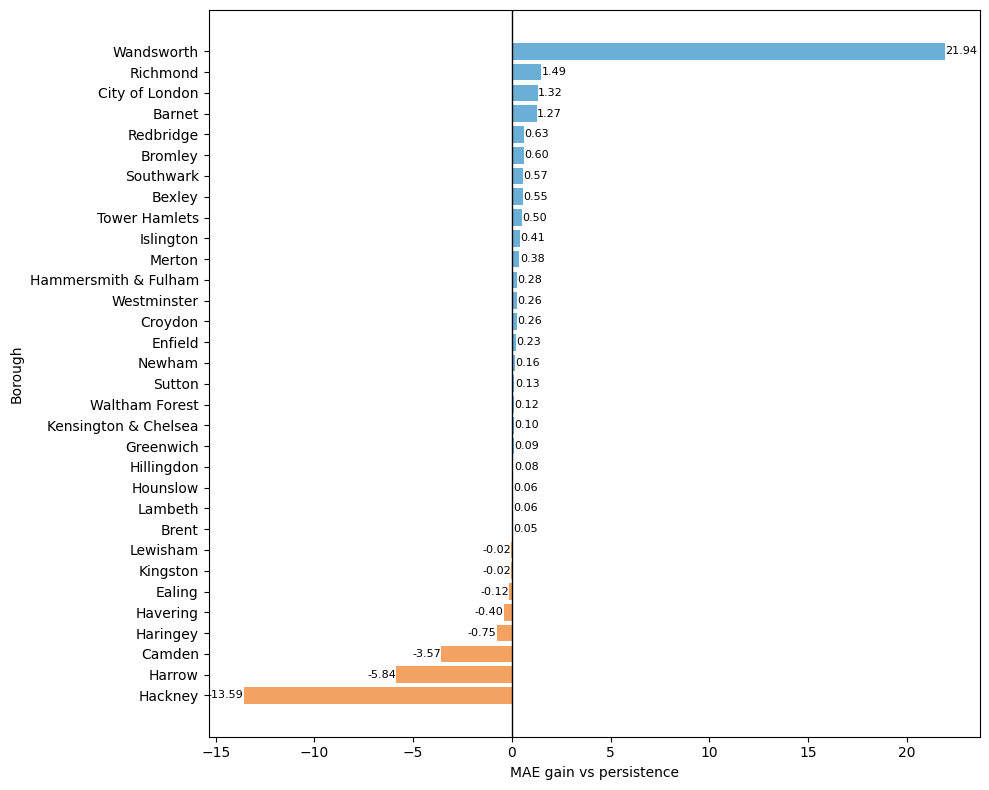

In [34]:
# ============================================
# 4.7 - MDT GAIN VS PERSISTENCE BY BOROUGH
# ============================================

best_model_mdt = all_results["median_decision_time"]["metrics"]["MAE"].idxmin()

borough_mdt_compare = borough_mdt[[
    "lpa_name", "n_obs", "Persistence_MAE", f"{best_model_mdt}_MAE"
]].copy()

borough_mdt_compare["MAE_gain_vs_persistence"] = (
    borough_mdt_compare["Persistence_MAE"] - borough_mdt_compare[f"{best_model_mdt}_MAE"]
)

borough_mdt_compare = borough_mdt_compare.sort_values("MAE_gain_vs_persistence")

# conditional colors: blue for positive, orange for negative
colors = [
    "#6BAED6" if v >= 0 else "#F4A261"
    for v in borough_mdt_compare["MAE_gain_vs_persistence"]
]

plt.figure(figsize=(10, 8))
bars = plt.barh(
    borough_mdt_compare["lpa_name"],
    borough_mdt_compare["MAE_gain_vs_persistence"],
    color=colors,
    edgecolor="none"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("MAE gain vs persistence")
plt.ylabel("Borough")

for bar, value in zip(bars, borough_mdt_compare["MAE_gain_vs_persistence"]):
    plt.text(
        value + 0.02 if value >= 0 else value - 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=8
    )

plt.tight_layout()
plt.show()

## Generalization and Stability Checks

A set of additional diagnostic checks is carried out to assess whether the observed out-of-sample performance may reflect overfitting or, alternatively, a more difficult test period. These checks focus on three aspects. First, the distribution of the target variables is compared between the training and test samples in order to identify changes in volatility or the presence of extreme observations. Second, borough coverage across the 2025 test period is examined to verify whether later months are affected by reduced completeness. Third, fold-level cross-validation RMSE is inspected for the tuned models to assess whether performance is stable across the training period or varies substantially over time. Taken together, these diagnostics provide a more robust basis for interpreting the final model results.

In [35]:
# ============================================
# K. TRAIN VS TEST DIAGNOSTICS
# ============================================

def target_distribution_summary(train_df, test_df, target):
    summary = pd.DataFrame({
        "sample": ["train", "test"],
        "n_obs": [train_df[target].notna().sum(), test_df[target].notna().sum()],
        "mean": [train_df[target].mean(), test_df[target].mean()],
        "median": [train_df[target].median(), test_df[target].median()],
        "std": [train_df[target].std(), test_df[target].std()],
        "min": [train_df[target].min(), test_df[target].min()],
        "max": [train_df[target].max(), test_df[target].max()]
    }).round(4)
    return summary

for target in datasets:
    print(f"\n=== {target.upper()} : train vs test distribution ===")
    print(target_distribution_summary(
        datasets[target]["train"],
        datasets[target]["test"],
        target
    ))


=== MEDIAN_DECISION_TIME : train vs test distribution ===
  sample  n_obs     mean  median      std  min    max
0  train   2207  58.0483    56.0  18.3623  0.0  420.0
1   test    359  57.7298    56.0  42.6860  0.0  755.0

=== APPROVAL_RATE : train vs test distribution ===
  sample  n_obs    mean  median     std  min  max
0  train   2207  0.6987  0.6941  0.1162  0.0  1.0
1   test    359  0.7062  0.7333  0.1714  0.0  1.0


In [36]:
# Most extreme 2025 MDT observations
extreme_mdt_test = datasets["median_decision_time"]["test"][
    ["lpa_name", "year_month", "median_decision_time", "decision_volume", "shock_intensity"]
].sort_values("median_decision_time", ascending=False)

print(extreme_mdt_test.head(15))

                  lpa_name year_month  median_decision_time  decision_volume  \
665                 Ealing 2025-11-01                 755.0                1   
2569            Wandsworth 2025-03-01                 369.0              587   
331                Bromley 2025-10-01                 150.0                1   
490         City of London 2025-03-01                 115.0              102   
498         City of London 2025-11-01                 112.0              121   
499         City of London 2025-12-01                 112.0              151   
2576            Wandsworth 2025-10-01                 106.0              599   
488         City of London 2025-01-01                 104.0               86   
2575            Wandsworth 2025-09-01                 103.0              537   
988   Hammersmith & Fulham 2025-02-01                 101.0              196   
494         City of London 2025-07-01                  93.0              119   
497         City of London 2025-10-01   

In [37]:
# ============================================
# L. 2025 MONTHLY TEST COVERAGE
# ============================================

for target in datasets:
    print(f"\n=== {target.upper()} : borough coverage by test month ===")
    coverage = (
        datasets[target]["test"]
        .groupby("year_month")["lpa_name"]
        .nunique()
        .reset_index(name="n_boroughs")
    )
    print(coverage)


=== MEDIAN_DECISION_TIME : borough coverage by test month ===
   year_month  n_boroughs
0  2025-01-01          32
1  2025-02-01          31
2  2025-03-01          32
3  2025-04-01          32
4  2025-05-01          32
5  2025-06-01          32
6  2025-07-01          30
7  2025-08-01          28
8  2025-09-01          29
9  2025-10-01          28
10 2025-11-01          29
11 2025-12-01          24

=== APPROVAL_RATE : borough coverage by test month ===
   year_month  n_boroughs
0  2025-01-01          32
1  2025-02-01          31
2  2025-03-01          32
3  2025-04-01          32
4  2025-05-01          32
5  2025-06-01          32
6  2025-07-01          30
7  2025-08-01          28
8  2025-09-01          29
9  2025-10-01          28
10 2025-11-01          29
11 2025-12-01          24


In [38]:
# ============================================
# M. CV FOLD STABILITY
# ============================================

def extract_cv_fold_scores(search_obj):
    n_splits = search_obj.n_splits_
    best_idx = search_obj.best_index_
    rows = []

    for i in range(n_splits):
        score = search_obj.cv_results_[f"split{i}_test_score"][best_idx]
        rows.append({
            "fold": i + 1,
            "rmse": -score
        })

    return pd.DataFrame(rows)

for target in all_results:
    print(f"\n===== CV fold RMSE: {target} =====")

    ridge_folds = extract_cv_fold_scores(all_results[target]["ridge_search"])
    rf_folds = extract_cv_fold_scores(all_results[target]["rf_search"])
    hgb_folds = extract_cv_fold_scores(all_results[target]["hgb_search"])

    print("\nRidge")
    print(ridge_folds)

    print("\nRandom Forest")
    print(rf_folds)

    print("\nHistGradientBoosting")
    print(hgb_folds)


===== CV fold RMSE: median_decision_time =====

Ridge
   fold       rmse
0     1   5.728794
1     2  20.929230
2     3   7.695514
3     4   4.023884
4     5  26.319601

Random Forest
   fold       rmse
0     1   6.521147
1     2  19.945285
2     3   8.176123
3     4   4.770714
4     5  25.117366

HistGradientBoosting
   fold       rmse
0     1   6.789505
1     2  20.059740
2     3   8.435130
3     4   5.436103
4     5  24.929704

===== CV fold RMSE: approval_rate =====

Ridge
   fold      rmse
0     1  0.051934
1     2  0.090780
2     3  0.053136
3     4  0.046462
4     5  0.080963

Random Forest
   fold      rmse
0     1  0.057827
1     2  0.119281
2     3  0.052923
3     4  0.048017
4     5  0.077582

HistGradientBoosting
   fold      rmse
0     1  0.070744
1     2  0.115533
2     3  0.053730
3     4  0.048207
4     5  0.075819


## Interpretation of the Diagnostic Checks

The diagnostic results indicate that the weaker out-of-sample performance observed in 2025 is not primarily driven by severe model-specific overfitting. Instead, the evidence points to a structurally more difficult test period, especially for median decision time. While the central tendency of the target remains broadly stable between training and test samples, the variance and extreme values increase markedly in 2025, indicating a more volatile forecasting environment. This is reinforced by the presence of a small number of very large decision-time observations and by the reduction in borough coverage toward the end of 2025, which is consistent with the incomplete availability of recently decided cases. In addition, the fold-level cross-validation results show substantial variation within the training period itself, suggesting that the underlying process is not temporally stable. These findings support a cautious interpretation of the predictive results: the models are evaluated on a test period that is both noisier and less complete than the training data, particularly for median decision time.

## Extended Modeling Strategy

This section extends the baseline modeling framework by introducing additional models,
feature selection experiments, and interpretability techniques.

The goal is to assess whether more advanced methods improve predictive performance
and to better understand the drivers of model predictions.

The following extensions are implemented:
- Gradient boosting model (XGBoost)
- Additional hyperparameter tuning
- Feature subset experiments
- SHAP-based model interpretation
- Classical time-series benchmark (optional)

All experiments are conducted using the same temporal split to ensure comparability.

## XGBoost (gradient boosting for tabular panel-style forecasting)

This section adds XGBoost as an additional nonlinear machine-learning model to the baseline
comparison. XGBoost is widely used in structured/tabular prediction tasks because it can
capture nonlinear relationships and interactions that linear models may miss.

In this notebook, XGBoost is trained using the same time-series cross-validation strategy
as the other machine-learning models. This ensures that the comparison remains fair and
that no future information leaks into model selection.

A relatively compact hyperparameter grid is used at this stage. The objective here is not
to fully exhaust the search space, but to establish a strong additional benchmark that can
later be refined in a dedicated hyperparameter optimization section.

In [39]:
def fit_xgb_with_cv(X_train, y_train):
    """
    Fit an XGBoost regressor using the same TimeSeriesSplit strategy
    already used in the baseline framework.

    Why this model:
    - XGBoost is a strong benchmark for structured/tabular data.
    - It can capture nonlinear effects and interactions between lagged,
      seasonal, and shock-related variables.
    - It integrates well with GridSearchCV through its sklearn interface.

    Why this grid:
    - It is intentionally moderate in size, so this first extension remains
      computationally manageable.
    - The grid explores the main bias-variance controls:
        * n_estimators      -> number of boosting rounds
        * max_depth         -> tree complexity
        * learning_rate     -> step size of boosting
        * min_child_weight  -> controls how easily splits are made
        * subsample         -> row sampling to reduce overfitting
        * colsample_bytree  -> feature sampling to reduce overfitting
    """

    xgb = XGBRegressor(
        objective="reg:squarederror",   # standard regression loss
        random_state=42,
        n_jobs=-1,
        tree_method="hist"              # faster histogram-based tree building
    )

    param_grid = {
        "n_estimators": [200, 400],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.03, 0.05, 0.1],
        "min_child_weight": [1, 3, 5],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    }

    search = GridSearchCV(
        estimator=xgb,
        param_grid=param_grid,
        cv=tscv,   # keep the exact same temporal CV logic as the rest of the notebook
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    return search

## XGBoost training and evaluation

This section evaluates XGBoost using the same train/test split and the same
target-specific feature sets defined in the baseline framework.

The model is trained separately for each target using time-series cross-validation.
Its performance is then assessed on the 2025 holdout test set and compared with
the existing baseline models.

The results are integrated into the same storage structure used previously, so that
all models can be compared consistently in later summary tables and interpretation steps.

In [40]:
for target, data in datasets.items():
    print(f"\n==============================")
    print(f"XGBOOST EXTENSION FOR TARGET: {target}")
    print(f"==============================")

    # Reuse the existing train/test objects so that the extension remains comparable with the baseline models.
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]

    # 1) Estimate XGBoost under the same time-series cross-validation scheme.
    xgb_search = fit_xgb_with_cv(X_train, y_train)
    xgb_best = xgb_search.best_estimator_

    # 2) Generate holdout predictions for the 2025 test sample.
    pred_xgb = xgb_best.predict(X_test)

    # 3) Add the new metrics to the existing comparison table.
    xgb_metrics = regression_metrics(y_test, pred_xgb)
    all_results[target]["metrics"].loc["XGBoost"] = xgb_metrics
    all_results[target]["metrics"] = all_results[target]["metrics"].sort_values("MAE")

    # 4) Store row-level predictions for later diagnostics.
    all_results[target]["predictions"]["XGBoost"] = pred_xgb

    # 5) Store the fitted objects so they can be reused in later extension blocks.
    all_results[target]["xgb_model"] = xgb_best
    all_results[target]["xgb_search"] = xgb_search

    print_best_params("XGBoost", xgb_search)

    print("\nUpdated metrics table:")
    print(all_results[target]["metrics"])



XGBOOST EXTENSION FOR TARGET: median_decision_time


c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


XGBoost best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200, 'subsample': 1.0}
XGBoost best CV RMSE: 13.0968

Updated metrics table:
                           MAE       RMSE        R2
RandomForest          7.218123  41.517374  0.051362
HistGradientBoosting  7.293256  41.672817  0.044246
XGBoost               7.447724  41.493971  0.052432
Persistence           7.625348  44.603445 -0.094907
FixedEffects          8.891848  41.887733  0.034362
Ridge                 9.137120  42.001011  0.029132

XGBOOST EXTENSION FOR TARGET: approval_rate
XGBoost best params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200, 'subsample': 0.8}
XGBoost best CV RMSE: 0.0761

Updated metrics table:
                           MAE      RMSE        R2
Persistence           0.053520  0.099296  0.663587
FixedEffects          0.058931  0.101607  0.647743
Ridge                 0.059662  0.10

c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Extended Model Comparison (Cross-Validation vs Test)

This section compares cross-validation RMSE and test RMSE for all search-based models,
including XGBoost, in order to assess temporal generalization and potential overfitting.

The comparison focuses on the difference between validation performance and
out-of-sample performance on the 2025 holdout sample.

In [41]:
# ============================================
# EXTENDED MODEL COMPARISON: CV RMSE VS TEST RMSE
# ============================================

cv_test_summary_rows = []

for target in all_results:
    metrics_df = all_results[target]["metrics"]

    # The extended comparison includes the original search-based models plus XGBoost.
    model_specs = [
        ("Ridge", "ridge_search"),
        ("RandomForest", "rf_search"),
        ("HistGradientBoosting", "hgb_search"),
        ("XGBoost", "xgb_search")
    ]

    for model_name, search_key in model_specs:
        cv_rmse = -all_results[target][search_key].best_score_
        test_rmse = metrics_df.loc[model_name, "RMSE"]

        cv_test_summary_rows.append({
            "target": target,
            "model": model_name,
            "cv_rmse": cv_rmse,
            "test_rmse": test_rmse,
            "gap_test_minus_cv": test_rmse - cv_rmse
        })

cv_test_summary_ext = (
    pd.DataFrame(cv_test_summary_rows)
    .sort_values(["target", "test_rmse"])
    .reset_index(drop=True)
    .round(4)
)

print(cv_test_summary_ext)


                 target                 model  cv_rmse  test_rmse  \
0         approval_rate                 Ridge   0.0647     0.1025   
1         approval_rate          RandomForest   0.0711     0.1154   
2         approval_rate  HistGradientBoosting   0.0728     0.1196   
3         approval_rate               XGBoost   0.0761     0.1221   
4  median_decision_time               XGBoost  13.0968    41.4940   
5  median_decision_time          RandomForest  12.9061    41.5174   
6  median_decision_time  HistGradientBoosting  13.1300    41.6728   
7  median_decision_time                 Ridge  12.9394    42.0010   

   gap_test_minus_cv  
0             0.0379  
1             0.0443  
2             0.0467  
3             0.0460  
4            28.3972  
5            28.6112  
6            28.5428  
7            29.0616  


In [42]:
# Display the extended validation-to-test comparison target by target.
for target in cv_test_summary_ext["target"].unique():
    print(f"\n===== {target.upper()} =====")
    print(
        cv_test_summary_ext[cv_test_summary_ext["target"] == target]
        .sort_values("test_rmse")
        .reset_index(drop=True)
    )



===== APPROVAL_RATE =====
          target                 model  cv_rmse  test_rmse  gap_test_minus_cv
0  approval_rate                 Ridge   0.0647     0.1025             0.0379
1  approval_rate          RandomForest   0.0711     0.1154             0.0443
2  approval_rate  HistGradientBoosting   0.0728     0.1196             0.0467
3  approval_rate               XGBoost   0.0761     0.1221             0.0460

===== MEDIAN_DECISION_TIME =====
                 target                 model  cv_rmse  test_rmse  \
0  median_decision_time               XGBoost  13.0968    41.4940   
1  median_decision_time          RandomForest  12.9061    41.5174   
2  median_decision_time  HistGradientBoosting  13.1300    41.6728   
3  median_decision_time                 Ridge  12.9394    42.0010   

   gap_test_minus_cv  
0            28.3972  
1            28.6112  
2            28.5428  
3            29.0616  


## Extended Fold Stability Analysis

This section examines the variation in cross-validation RMSE across temporal folds for the search-based models, including XGBoost.

The objective is to assess whether model performance remains stable across validation periods or varies substantially from one fold to another.

In [43]:
# ============================================
# EXTENDED FOLD STABILITY ANALYSIS
# ============================================

def extract_cv_fold_scores(search_obj, model_name, target_name):
    fold_rows = []

    # GridSearchCV stores one score per split for every parameter combination.
    split_cols = [col for col in search_obj.cv_results_.keys() if col.startswith("split") and col.endswith("_test_score")]

    # The selected row corresponds to the best parameter combination.
    best_index = search_obj.best_index_

    for col in split_cols:
        fold_name = col.replace("_test_score", "")
        rmse_value = -search_obj.cv_results_[col][best_index]

        fold_rows.append({
            "target": target_name,
            "model": model_name,
            "fold": fold_name,
            "rmse": rmse_value
        })

    return fold_rows


fold_stability_rows_ext = []

for target in all_results:
    fold_stability_rows_ext.extend(
        extract_cv_fold_scores(all_results[target]["ridge_search"], "Ridge", target)
    )
    fold_stability_rows_ext.extend(
        extract_cv_fold_scores(all_results[target]["rf_search"], "RandomForest", target)
    )
    fold_stability_rows_ext.extend(
        extract_cv_fold_scores(all_results[target]["hgb_search"], "HistGradientBoosting", target)
    )
    fold_stability_rows_ext.extend(
        extract_cv_fold_scores(all_results[target]["xgb_search"], "XGBoost", target)
    )

fold_stability_ext = (
    pd.DataFrame(fold_stability_rows_ext)
    .sort_values(["target", "model", "fold"])
    .reset_index(drop=True)
    .round(4)
)

print(fold_stability_ext)


                  target                 model    fold     rmse
0          approval_rate  HistGradientBoosting  split0   0.0707
1          approval_rate  HistGradientBoosting  split1   0.1155
2          approval_rate  HistGradientBoosting  split2   0.0537
3          approval_rate  HistGradientBoosting  split3   0.0482
4          approval_rate  HistGradientBoosting  split4   0.0758
5          approval_rate          RandomForest  split0   0.0578
6          approval_rate          RandomForest  split1   0.1193
7          approval_rate          RandomForest  split2   0.0529
8          approval_rate          RandomForest  split3   0.0480
9          approval_rate          RandomForest  split4   0.0776
10         approval_rate                 Ridge  split0   0.0519
11         approval_rate                 Ridge  split1   0.0908
12         approval_rate                 Ridge  split2   0.0531
13         approval_rate                 Ridge  split3   0.0465
14         approval_rate                

In [44]:
# Summarize the central tendency and spread of fold-level RMSE for each model.
fold_stability_summary_ext = (
    fold_stability_ext
    .groupby(["target", "model"], as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        min_rmse=("rmse", "min"),
        max_rmse=("rmse", "max")
    )
    .sort_values(["target", "mean_rmse"])
    .reset_index(drop=True)
    .round(4)
)

print(fold_stability_summary_ext)


                 target                 model  mean_rmse  std_rmse  min_rmse  \
0         approval_rate                 Ridge     0.0647    0.0199    0.0465   
1         approval_rate          RandomForest     0.0711    0.0292    0.0480   
2         approval_rate  HistGradientBoosting     0.0728    0.0265    0.0482   
3         approval_rate               XGBoost     0.0760    0.0283    0.0482   
4  median_decision_time          RandomForest    12.9061    9.0553    4.7707   
5  median_decision_time                 Ridge    12.9394   10.0230    4.0239   
6  median_decision_time               XGBoost    13.0968    8.8497    5.1546   
7  median_decision_time  HistGradientBoosting    13.1300    8.7848    5.4361   

   max_rmse  
0    0.0908  
1    0.1193  
2    0.1155  
3    0.1195  
4   25.1174  
5   26.3196  
6   25.4126  
7   24.9297  


## Hyperparameter Optimization

To assess whether model performance can be improved, selected models are further tuned
using a more focused hyperparameter search.

The goal is not exhaustive optimization, but rather to evaluate whether tuning
provides meaningful performance gains over baseline configurations.

In [45]:
# Focused tuning is restricted to the main tree-based MDT models.
# ============================================
# HYPERPARAMETER OPTIMIZATION
# ============================================

def fit_rf_with_cv_tuned(X_train, y_train):
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)

    param_grid = {
        "n_estimators": [300, 500],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", 0.7]
    }

    search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    return search


def fit_hgb_with_cv_tuned(X_train, y_train):
    hgb = HistGradientBoostingRegressor(random_state=42)

    param_grid = {
        "learning_rate": [0.03, 0.05, 0.08],
        "max_iter": [200, 300],
        "max_depth": [3, 5, None],
        "min_samples_leaf": [10, 20],
        "l2_regularization": [0.0, 0.1]
    }

    search = GridSearchCV(
        estimator=hgb,
        param_grid=param_grid,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    return search


def fit_xgb_with_cv_tuned(X_train, y_train):
    xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    )

    param_grid = {
        "n_estimators": [150, 200, 300],
        "max_depth": [2, 3, 4],
        "learning_rate": [0.03, 0.05, 0.1],
        "min_child_weight": [3, 5],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.6, 0.8]
    }

    search = GridSearchCV(
        estimator=xgb,
        param_grid=param_grid,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    return search


target = "median_decision_time"

X_train = datasets[target]["X_train"]
X_test = datasets[target]["X_test"]
y_train = datasets[target]["y_train"]
y_test = datasets[target]["y_test"]

tuning_results_ext = {}

# Random Forest
rf_search_tuned = fit_rf_with_cv_tuned(X_train, y_train)
rf_model_tuned = rf_search_tuned.best_estimator_
rf_pred_tuned = rf_model_tuned.predict(X_test)
rf_metrics_tuned = regression_metrics(y_test, rf_pred_tuned)

tuning_results_ext["RandomForest_tuned"] = {
    "search": rf_search_tuned,
    "model": rf_model_tuned,
    "metrics": rf_metrics_tuned
}

print_best_params("RandomForest_tuned", rf_search_tuned)

# HistGradientBoosting
hgb_search_tuned = fit_hgb_with_cv_tuned(X_train, y_train)
hgb_model_tuned = hgb_search_tuned.best_estimator_
hgb_pred_tuned = hgb_model_tuned.predict(X_test)
hgb_metrics_tuned = regression_metrics(y_test, hgb_pred_tuned)

tuning_results_ext["HistGradientBoosting_tuned"] = {
    "search": hgb_search_tuned,
    "model": hgb_model_tuned,
    "metrics": hgb_metrics_tuned
}

print_best_params("HistGradientBoosting_tuned", hgb_search_tuned)

# XGBoost
xgb_search_tuned = fit_xgb_with_cv_tuned(X_train, y_train)
xgb_model_tuned = xgb_search_tuned.best_estimator_
xgb_pred_tuned = xgb_model_tuned.predict(X_test)
xgb_metrics_tuned = regression_metrics(y_test, xgb_pred_tuned)

tuning_results_ext["XGBoost_tuned"] = {
    "search": xgb_search_tuned,
    "model": xgb_model_tuned,
    "metrics": xgb_metrics_tuned
}

print_best_params("XGBoost_tuned", xgb_search_tuned)

# Store tuned objects inside the existing results structure.
all_results[target]["rf_search_tuned"] = rf_search_tuned
all_results[target]["rf_model_tuned"] = rf_model_tuned

all_results[target]["hgb_search_tuned"] = hgb_search_tuned
all_results[target]["hgb_model_tuned"] = hgb_model_tuned

all_results[target]["xgb_search_tuned"] = xgb_search_tuned
all_results[target]["xgb_model_tuned"] = xgb_model_tuned

# Comparison table: baseline vs tuned
tuning_comparison_rows = []

baseline_map = {
    "RandomForest": "rf_search",
    "HistGradientBoosting": "hgb_search",
    "XGBoost": "xgb_search"
}

tuned_map = {
    "RandomForest": "RandomForest_tuned",
    "HistGradientBoosting": "HistGradientBoosting_tuned",
    "XGBoost": "XGBoost_tuned"
}

for model_name in baseline_map:
    baseline_cv_rmse = -all_results[target][baseline_map[model_name]].best_score_
    baseline_test_rmse = all_results[target]["metrics"].loc[model_name, "RMSE"]

    tuned_cv_rmse = -tuning_results_ext[tuned_map[model_name]]["search"].best_score_
    tuned_test_rmse = tuning_results_ext[tuned_map[model_name]]["metrics"]["RMSE"]

    tuning_comparison_rows.append({
        "target": target,
        "model": model_name,
        "baseline_cv_rmse": baseline_cv_rmse,
        "baseline_test_rmse": baseline_test_rmse,
        "tuned_cv_rmse": tuned_cv_rmse,
        "tuned_test_rmse": tuned_test_rmse,
        "delta_test_rmse": tuned_test_rmse - baseline_test_rmse
    })

tuning_comparison_ext = (
    pd.DataFrame(tuning_comparison_rows)
    .sort_values("tuned_test_rmse")
    .reset_index(drop=True)
    .round(4)
)

print(tuning_comparison_ext)

c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


RandomForest_tuned best params: {'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 500}
RandomForest_tuned best CV RMSE: 13.1953


c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


HistGradientBoosting_tuned best params: {'l2_regularization': 0.0, 'learning_rate': 0.03, 'max_depth': 3, 'max_iter': 200, 'min_samples_leaf': 20}
HistGradientBoosting_tuned best CV RMSE: 13.1300
XGBoost_tuned best params: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 150, 'subsample': 0.8}
XGBoost_tuned best CV RMSE: 13.0187
                 target                 model  baseline_cv_rmse  \
0  median_decision_time  HistGradientBoosting           13.1300   
1  median_decision_time               XGBoost           13.0968   
2  median_decision_time          RandomForest           12.9061   

   baseline_test_rmse  tuned_cv_rmse  tuned_test_rmse  delta_test_rmse  
0             41.6728        13.1300          41.6728           0.0000  
1             41.4940        13.0187          41.6971           0.2031  
2             41.5174        13.1953          41.7199           0.2026  


c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Feature Subset Experiments

This section evaluates whether reduced feature sets improve generalization for median decision time.

The comparison focuses on parsimonious specifications motivated by the previous feature importance results. In particular, the objective is to assess whether most predictive information is concentrated in recent target dynamics, baseline conditions, and a small number of workload-related variables.

In [46]:
# Reduced feature sets are compared under the same XGBoost framework.
# ============================================
# FEATURE SUBSET EXPERIMENTS
# ============================================

target = "median_decision_time"

train_df = datasets[target]["train"].copy()
test_df = datasets[target]["test"].copy()
y_train = datasets[target]["y_train"]
y_test = datasets[target]["y_test"]

feature_subsets_mdt = {
    "full": [
        "decision_volume_lag1",
        "decision_volume_lag3",
        "decision_volume_roll3",
        "shock_flag_lag1",
        "shock_flag_lag3",
        "shock_intensity_lag1",
        "shock_intensity_lag3",
        "p90_volume",
        "baseline_mdt",
        "baseline_ar",
        "month_sin",
        "month_cos",
        "median_decision_time_lag1",
        "median_decision_time_lag3"
    ],
    "lags_workload": [
        "median_decision_time_lag1",
        "median_decision_time_lag3",
        "decision_volume_lag1",
        "decision_volume_lag3",
        "decision_volume_roll3"
    ],
    "core_structural": [
        "median_decision_time_lag1",
        "median_decision_time_lag3",
        "baseline_mdt",
        "month_sin",
        "month_cos",
        "decision_volume_lag1",
        "decision_volume_roll3",
        "shock_intensity_lag1"
    ],
    "top_k_importance": [
        "median_decision_time_lag1",
        "baseline_mdt",
        "median_decision_time_lag3",
        "shock_intensity_lag1",
        "month_cos",
        "decision_volume_lag1",
        "month_sin",
        "decision_volume_roll3"
    ]
}

subset_results_ext = {}

for subset_name, feature_cols in feature_subsets_mdt.items():
    X_train_subset = train_df[feature_cols].copy()
    X_test_subset = test_df[feature_cols].copy()

    xgb_search_subset = fit_xgb_with_cv(X_train_subset, y_train)
    xgb_model_subset = xgb_search_subset.best_estimator_
    xgb_pred_subset = xgb_model_subset.predict(X_test_subset)
    xgb_metrics_subset = regression_metrics(y_test, xgb_pred_subset)

    subset_results_ext[subset_name] = {
        "features": feature_cols,
        "n_features": len(feature_cols),
        "search": xgb_search_subset,
        "model": xgb_model_subset,
        "metrics": xgb_metrics_subset
    }

    print_best_params(f"XGBoost_{subset_name}", xgb_search_subset)

subset_comparison_rows = []

for subset_name, result in subset_results_ext.items():
    subset_comparison_rows.append({
        "target": target,
        "subset": subset_name,
        "n_features": result["n_features"],
        "cv_rmse": -result["search"].best_score_,
        "test_mae": result["metrics"]["MAE"],
        "test_rmse": result["metrics"]["RMSE"],
        "test_r2": result["metrics"]["R2"],
        "gap_test_minus_cv": result["metrics"]["RMSE"] - (-result["search"].best_score_)
    })

subset_comparison_ext = (
    pd.DataFrame(subset_comparison_rows)
    .sort_values("test_rmse")
    .reset_index(drop=True)
    .round(4)
)

print(subset_comparison_ext)

c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


XGBoost_full best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200, 'subsample': 1.0}
XGBoost_full best CV RMSE: 13.0968


c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


XGBoost_lags_workload best params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200, 'subsample': 1.0}
XGBoost_lags_workload best CV RMSE: 13.0432


c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


XGBoost_core_structural best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 400, 'subsample': 1.0}
XGBoost_core_structural best CV RMSE: 12.9098


c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


XGBoost_top_k_importance best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 400, 'subsample': 1.0}
XGBoost_top_k_importance best CV RMSE: 12.8075
                 target            subset  n_features  cv_rmse  test_mae  \
0  median_decision_time     lags_workload           5  13.0432    7.1715   
1  median_decision_time  top_k_importance           8  12.8075    7.2520   
2  median_decision_time              full          14  13.0968    7.4477   
3  median_decision_time   core_structural           8  12.9098    7.4149   

   test_rmse  test_r2  gap_test_minus_cv  
0    41.4663   0.0537            28.4231  
1    41.4729   0.0534            28.6655  
2    41.4940   0.0524            28.3972  
3    41.5092   0.0517            28.5995  


c:\Users\Jose Miguel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Model Interpretability with SHAP

This section uses SHAP values to interpret the best-performing reduced XGBoost specification for median decision time.

The objective is to assess how the selected lag and workload variables contribute to the predictions and whether the learned relationships are consistent with the previous model comparison results.

In [47]:
# ============================================
# SHAP ANALYSIS FOR THE BEST SUBSET MODEL
# ============================================

best_subset_name = "lags_workload"
target = "median_decision_time"

best_subset_features = subset_results_ext[best_subset_name]["features"]
best_subset_model = subset_results_ext[best_subset_name]["model"]

X_train_best_subset = datasets[target]["train"][best_subset_features].copy()
X_test_best_subset = datasets[target]["test"][best_subset_features].copy()

# TreeExplainer is appropriate for XGBoost and supports efficient SHAP computation.
explainer = shap.TreeExplainer(best_subset_model)

# SHAP values are computed on the holdout test sample used in the performance evaluation.
shap_values_test = explainer.shap_values(X_test_best_subset)

print("Best subset model:", best_subset_name)
print("Number of features:", len(best_subset_features))
print("Features:", best_subset_features)


Best subset model: lags_workload
Number of features: 5
Features: ['median_decision_time_lag1', 'median_decision_time_lag3', 'decision_volume_lag1', 'decision_volume_lag3', 'decision_volume_roll3']


## SHAP Summary Plot

This plot ranks the features according to their overall contribution to prediction variability and shows the direction of their effects across observations.

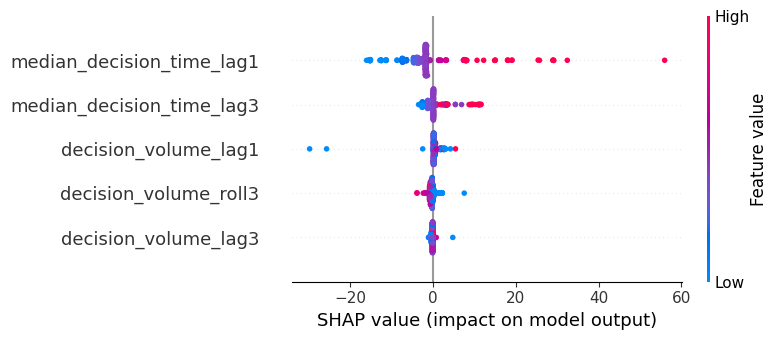

In [48]:
# Beeswarm summary of SHAP values across the test sample.
shap.summary_plot(
    shap_values_test,
    X_test_best_subset,
    show=True
)

## SHAP Importance Plot

This plot presents the mean absolute SHAP value of each feature, providing a global measure of feature importance for the reduced XGBoost model.

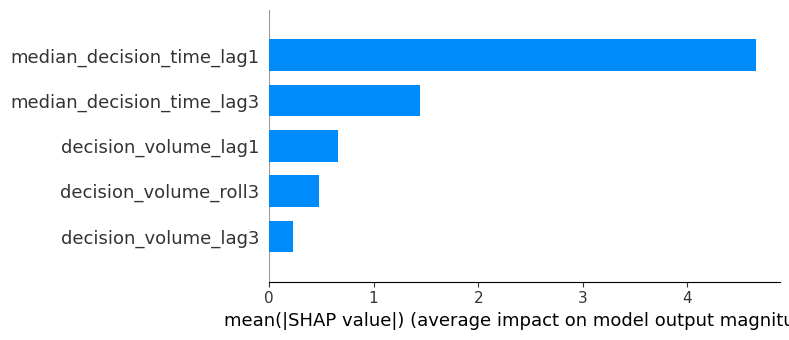

In [49]:
# Global SHAP importance ranked by mean absolute contribution.
shap.summary_plot(
    shap_values_test,
    X_test_best_subset,
    plot_type="bar",
    show=True
)

## Final Extended Model Comparison

This section consolidates the main results from the extended modelling exercises for median decision time.

The comparison includes the baseline XGBoost specification, the tuned tree-based models, and the reduced-feature XGBoost variants. The objective is to identify whether any of the additional experiments produced a meaningful improvement in out-of-sample performance.

In [50]:
# Consolidate baseline, tuned, and reduced-feature MDT specifications in one table.
# ============================================
# FINAL EXTENDED MODEL COMPARISON
# ============================================

target = "median_decision_time"

final_extended_rows = []

# Baseline search-based models
for model_name, search_key in [
    ("Ridge", "ridge_search"),
    ("RandomForest", "rf_search"),
    ("HistGradientBoosting", "hgb_search"),
    ("XGBoost_full", "xgb_search")
]:
    final_extended_rows.append({
        "target": target,
        "model_variant": model_name,
        "feature_set": "full",
        "n_features": len(all_results[target]["feature_cols"]),
        "cv_rmse": -all_results[target][search_key].best_score_,
        "test_mae": all_results[target]["metrics"].loc[
            "XGBoost" if model_name == "XGBoost_full" else model_name, "MAE"
        ],
        "test_rmse": all_results[target]["metrics"].loc[
            "XGBoost" if model_name == "XGBoost_full" else model_name, "RMSE"
        ],
        "test_r2": all_results[target]["metrics"].loc[
            "XGBoost" if model_name == "XGBoost_full" else model_name, "R2"
        ],
        "gap_test_minus_cv": (
            all_results[target]["metrics"].loc[
                "XGBoost" if model_name == "XGBoost_full" else model_name, "RMSE"
            ]
            - (-all_results[target][search_key].best_score_)
        )
    })

# Tuned models
for model_name, result_key in [
    ("RandomForest_tuned", "RandomForest_tuned"),
    ("HistGradientBoosting_tuned", "HistGradientBoosting_tuned"),
    ("XGBoost_tuned", "XGBoost_tuned")
]:
    final_extended_rows.append({
        "target": target,
        "model_variant": model_name,
        "feature_set": "baseline_full",
        "n_features": len(all_results[target]["feature_cols"]),
        "cv_rmse": -tuning_results_ext[result_key]["search"].best_score_,
        "test_mae": tuning_results_ext[result_key]["metrics"]["MAE"],
        "test_rmse": tuning_results_ext[result_key]["metrics"]["RMSE"],
        "test_r2": tuning_results_ext[result_key]["metrics"]["R2"],
        "gap_test_minus_cv": (
            tuning_results_ext[result_key]["metrics"]["RMSE"]
            - (-tuning_results_ext[result_key]["search"].best_score_)
        )
    })

# Feature subset models
for subset_name, result in subset_results_ext.items():
    if subset_name == "full":
        continue

    final_extended_rows.append({
        "target": target,
        "model_variant": f"XGBoost_{subset_name}",
        "feature_set": subset_name,
        "n_features": result["n_features"],
        "cv_rmse": -result["search"].best_score_,
        "test_mae": result["metrics"]["MAE"],
        "test_rmse": result["metrics"]["RMSE"],
        "test_r2": result["metrics"]["R2"],
        "gap_test_minus_cv": (
            result["metrics"]["RMSE"] - (-result["search"].best_score_)
        )
    })

final_extended_comparison = (
    pd.DataFrame(final_extended_rows)
    .sort_values(["test_rmse", "cv_rmse"])
    .reset_index(drop=True)
    .round(4)
)

print(final_extended_comparison)

                 target               model_variant       feature_set  \
0  median_decision_time       XGBoost_lags_workload     lags_workload   
1  median_decision_time    XGBoost_top_k_importance  top_k_importance   
2  median_decision_time                XGBoost_full              full   
3  median_decision_time     XGBoost_core_structural   core_structural   
4  median_decision_time                RandomForest              full   
5  median_decision_time        HistGradientBoosting              full   
6  median_decision_time  HistGradientBoosting_tuned     baseline_full   
7  median_decision_time               XGBoost_tuned     baseline_full   
8  median_decision_time          RandomForest_tuned     baseline_full   
9  median_decision_time                       Ridge              full   

   n_features  cv_rmse  test_mae  test_rmse  test_r2  gap_test_minus_cv  
0           5  13.0432    7.1715    41.4663   0.0537            28.4231  
1           8  12.8075    7.2520    41.4729   0.

## Best-Performing Extended Specifications

This table reports the strongest configurations in ascending order of test RMSE, highlighting whether reduced feature sets or tuned specifications improve out-of-sample performance.

In [51]:
# Display the top-ranked specifications from the extended comparison table.
print(final_extended_comparison.head(10))

                 target               model_variant       feature_set  \
0  median_decision_time       XGBoost_lags_workload     lags_workload   
1  median_decision_time    XGBoost_top_k_importance  top_k_importance   
2  median_decision_time                XGBoost_full              full   
3  median_decision_time     XGBoost_core_structural   core_structural   
4  median_decision_time                RandomForest              full   
5  median_decision_time        HistGradientBoosting              full   
6  median_decision_time  HistGradientBoosting_tuned     baseline_full   
7  median_decision_time               XGBoost_tuned     baseline_full   
8  median_decision_time          RandomForest_tuned     baseline_full   
9  median_decision_time                       Ridge              full   

   n_features  cv_rmse  test_mae  test_rmse  test_r2  gap_test_minus_cv  
0           5  13.0432    7.1715    41.4663   0.0537            28.4231  
1           8  12.8075    7.2520    41.4729   0.

## Comparison Relative to Baseline XGBoost

This table compares each extended specification with the baseline XGBoost model estimated on the full feature set.

In [52]:
# Re-express all extended specifications relative to the full-feature XGBoost baseline.
baseline_row = final_extended_comparison[
    final_extended_comparison["model_variant"] == "XGBoost_full"
].iloc[0]

baseline_test_rmse = baseline_row["test_rmse"]
baseline_cv_rmse = baseline_row["cv_rmse"]

final_extended_vs_baseline = final_extended_comparison.copy()
final_extended_vs_baseline["delta_test_rmse_vs_xgb_full"] = (
    final_extended_vs_baseline["test_rmse"] - baseline_test_rmse
)
final_extended_vs_baseline["delta_cv_rmse_vs_xgb_full"] = (
    final_extended_vs_baseline["cv_rmse"] - baseline_cv_rmse
)

final_extended_vs_baseline = final_extended_vs_baseline.round(4)

print(final_extended_vs_baseline)


                 target               model_variant       feature_set  \
0  median_decision_time       XGBoost_lags_workload     lags_workload   
1  median_decision_time    XGBoost_top_k_importance  top_k_importance   
2  median_decision_time                XGBoost_full              full   
3  median_decision_time     XGBoost_core_structural   core_structural   
4  median_decision_time                RandomForest              full   
5  median_decision_time        HistGradientBoosting              full   
6  median_decision_time  HistGradientBoosting_tuned     baseline_full   
7  median_decision_time               XGBoost_tuned     baseline_full   
8  median_decision_time          RandomForest_tuned     baseline_full   
9  median_decision_time                       Ridge              full   

   n_features  cv_rmse  test_mae  test_rmse  test_r2  gap_test_minus_cv  \
0           5  13.0432    7.1715    41.4663   0.0537            28.4231   
1           8  12.8075    7.2520    41.4729   

## Selected Final Model

This output identifies the specification with the lowest test RMSE in the extended modelling exercise.

In [53]:
# Extract the best-performing row from the extended comparison table.
best_extended_model = final_extended_comparison.iloc[0].copy()
print(best_extended_model)

target                median_decision_time
model_variant        XGBoost_lags_workload
feature_set                  lags_workload
n_features                               5
cv_rmse                            13.0432
test_mae                            7.1715
test_rmse                          41.4663
test_r2                             0.0537
gap_test_minus_cv                  28.4231
Name: 0, dtype: object


## Performance–Complexity Trade-off

This figure compares the number of features used by each specification with its out-of-sample RMSE for median decision time.

The objective is to assess whether increased model complexity leads to meaningful improvements in predictive performance.

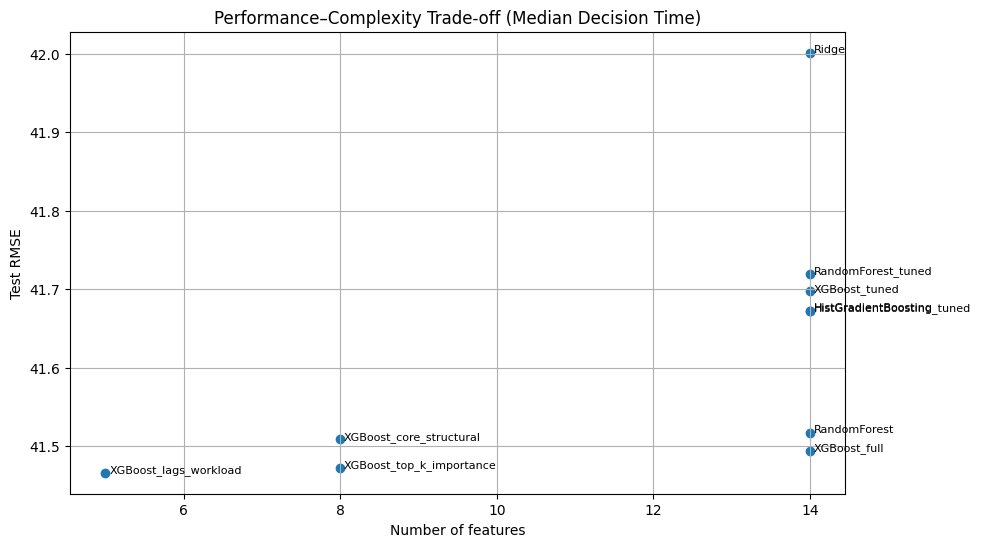

In [54]:
# Plot the trade-off between feature count and test RMSE.
plot_df = final_extended_comparison.copy()

plt.figure(figsize=(10, 6))
plt.scatter(plot_df["n_features"], plot_df["test_rmse"])

for _, row in plot_df.iterrows():
    plt.text(
        row["n_features"] + 0.05,
        row["test_rmse"],
        row["model_variant"],
        fontsize=8
    )

plt.xlabel("Number of features")
plt.ylabel("Test RMSE")
plt.title("Performance–Complexity Trade-off (Median Decision Time)")
plt.grid(True)
plt.show()

## Discussion of Results

The extended modelling exercises reinforce the main conclusion that median decision time is primarily driven by short-term temporal persistence, with recent workload acting as a secondary source of variation.

Among the additional model specifications, the reduced XGBoost model based on the `lags_workload` subset achieved the strongest out-of-sample performance, with a test RMSE of 41.4663. Although the improvement over the full-feature XGBoost specification was modest, the result indicates that most predictive information is concentrated in a small set of recent lag and workload variables.

The hyperparameter optimization stage did not produce meaningful gains in test performance. HistGradientBoosting remained unchanged, while the tuned Random Forest and XGBoost configurations performed slightly worse on the 2025 holdout sample. This suggests that the main limitation of the forecasting task is not insufficient hyperparameter search, but rather the temporal instability of the underlying process.

The SHAP analysis of the best-performing reduced XGBoost model further supports this interpretation. The dominant contribution of `median_decision_time_lag1`, followed by `median_decision_time_lag3`, confirms that recent borough-level decision-time dynamics are the strongest determinants of future performance. Workload-related variables, particularly recent and smoothed decision volume, provide an additional but clearly smaller contribution.

Overall, the extension layer does not support a narrative in which increasing model complexity materially transforms predictive performance. Instead, it shows that parsimonious models centered on recent decision-time dynamics provide the strongest and most interpretable results, while temporal instability across validation and test periods remains the main challenge.